Create a simple workflow to calculate the bmi of a person using weight and height details and categorize as obese, overweight or normal

In [9]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [19]:
#define state
class BMIState(TypedDict):
    weight_kg: float
    height_m: float
    bmi: float
    category: str

In [3]:
def calculate_bmi(state: BMIState) -> BMIState:
    weight = state['weight_kg']
    height = state['height_m']
    bmi = weight / (height ** 2)    
    state['bmi'] = round(bmi, 2)

    return state

In [28]:
def label_bmi(state: BMIState)-> BMIState:
    bmi = state['bmi']
    if bmi < 18.5:
        state['category'] = 'Underweight'
    elif 18.5 <= bmi < 25:
        state['category'] = 'Normal weight'
    elif 25 <= bmi < 29.9:
        state['category'] = 'Overweight'
    else:
        state['category'] = 'Obesity'
    return state

In [29]:
#define your graph
graph = StateGraph(BMIState)

#add notes to the graph
graph.add_node('calculate_bmi',calculate_bmi)
graph.add_node('label_bmi', label_bmi)

#add edges to the graph
graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi', 'label_bmi')
graph.add_edge('label_bmi', END)

#compile the graph
workflow = graph.compile()

#execute the graph
initial_state = {'weight_kg': 80, 'height_m': 1.75}
final_state = workflow.invoke(initial_state)

print(final_state)


{'weight_kg': 80, 'height_m': 1.75, 'bmi': 26.12, 'category': 'Overweight'}


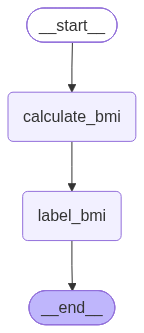

In [26]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())